<a href="https://colab.research.google.com/github/haikalbatubara/Customer-Segmentation-of-PT-Bank-Sumut-Based-on-Mobile-Banking-Transaction-Data-/blob/main/Clustering_Layanan_Internet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# CLUSTERING LAYANAN INTERNET

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans

df = pd.read_excel('trx_cleaned.xlsx')

internet_services = ['First Media', 'MNC PlayMedia', 'Speedy', 'Transvision', 'MyRepublic']
df_internet = df[df['biller_name'].isin(internet_services)].copy()

# Proses waktu transaksi
df_internet['received_time'] = pd.to_datetime(df_internet['received_time'], errors='coerce')
df_internet['day_of_week'] = df_internet['received_time'].dt.dayofweek  # Senin=0, Minggu=6

# Encode operator_code jadi angka (opsional)
df_internet['operator_encoded'] = LabelEncoder().fit_transform(df_internet['operator_code'].astype(str))

features = ['trx_value', 'day_of_week']
X = df_internet[features].dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


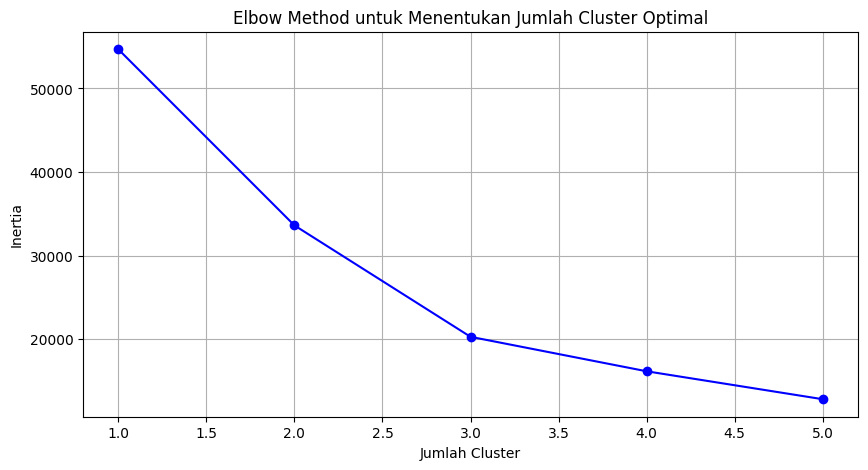

Delta 2-1: 21068.445232168488
Delta 3-2: 13328.572824074017
Delta 4-3: 4124.364332423129
Delta 5-4: 3341.123223033248


In [ ]:
# Elbow Method
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K_range = range(1, 6)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(K_range, inertia, 'bo-')
plt.xlabel('Jumlah Cluster')
plt.ylabel('Inertia')
plt.title('Elbow Method untuk Menentukan Jumlah Cluster Optimal')
plt.grid(True)
plt.show()


for i in range(1, len(inertia)):
    print(f"Delta {i+1}-{i}: {inertia[i-1] - inertia[i]}")


In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10) # Added n_init to suppress warning
df_cluster = df_internet.loc[X.index].copy()
df_cluster['Cluster'] = kmeans.fit_predict(X_scaled)

# Tambahkan koordinat centroid
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
centroids_df = pd.DataFrame(centroids, columns=features)

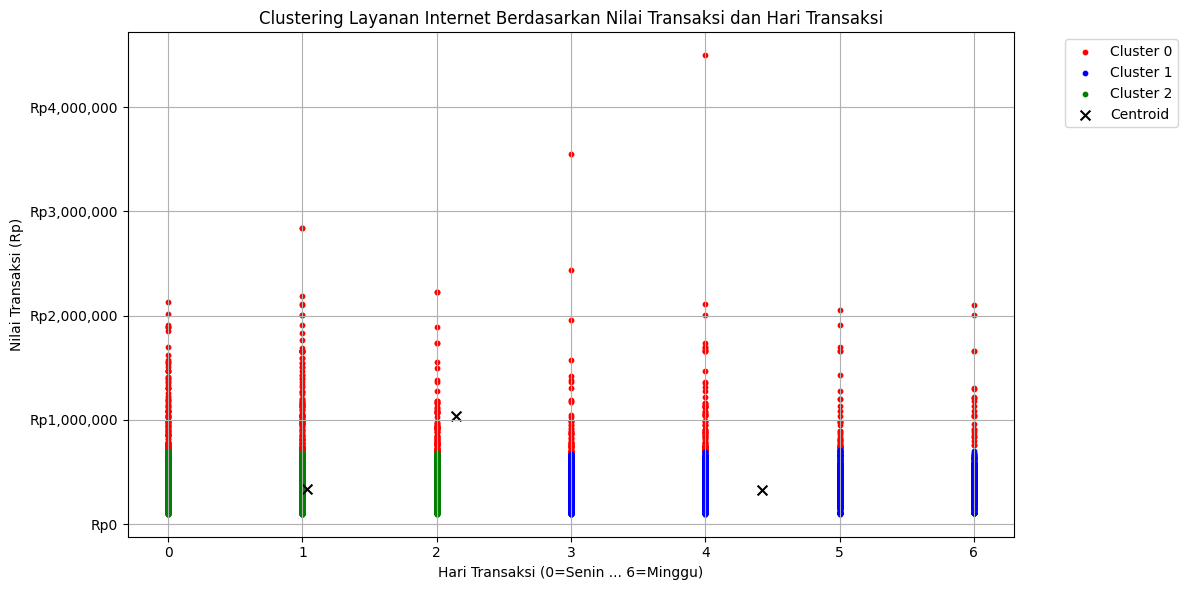

Statistik per Cluster:
        trx_value
            count
Cluster          
0             585
1           12357
2           14405


In [ ]:
plt.figure(figsize=(12, 6))
colors = ['red', 'blue', 'green']

for i in range(3):
    cluster_data = df_cluster[df_cluster['Cluster'] == i]
    plt.scatter(
        cluster_data['day_of_week'],
        cluster_data['trx_value'],
        s=10,
        color=colors[i],
        label=f'Cluster {i}'
    )

# Plot centroid
plt.scatter(
    centroids[:, 1], # day_of_week is the second feature
    centroids[:, 0], # trx_value is the first feature
    s=50,
    marker='x',
    color='black',
    label='Centroid'
)
# Label dan format sumbu
plt.title('Clustering Layanan Internet Berdasarkan Nilai Transaksi dan Hari Transaksi')
plt.xlabel('Hari Transaksi (0=Senin ... 6=Minggu)')
plt.ylabel('Nilai Transaksi (Rp)')
plt.grid(True)

# Format sumbu Y jadi format Rupiah
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'Rp{x:,.0f}'))

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Statistik deskriptif per cluster
stats = df_cluster.groupby('Cluster')[['trx_value']].agg(['count'])
print("Statistik per Cluster:")
print(stats)
